# **DATA 221: Final Project Code**

## **Part A: Data Wrangling**

### **1. Data Collection**

For this project, I built a country–year panel dataset covering roughly 50 countries from 2008 to 2020. **I use annual mean PM2.5 (EN.ATM.PM25.MC.M3) as the air quality measure.**

All other variables come from the World Bank Development Indicators to keep everything at the country level and consistent across time. I selected 14 variables that represent environmental, economic, and social aspects of sustainability while also checking that data coverage was strong across countries. Below is the code that I ran to get my data: 


``` python
import requests
import pandas as pd
import time

START_YEAR = 2008
END_YEAR = 2020

COUNTRIES = [
    "USA","CAN","GBR","DEU","FRA","ITA","ESP","JPN","KOR","IND",
    "BRA","MEX","AUS","NLD","SWE","NOR","ZAF","ARG","TUR","IDN",
    "CHE","POL","BEL","AUT","DNK","FIN","IRL","PRT","GRC","NZL",
    "CHN","THA","MYS","PHL","VNM","EGY","SAU","ARE","ISR","COL",
    "PER","CHL","CZE","HUN","ROU","UKR","PAK","BGD","NGA","KEN"
]

# See Legend description in the next cell
INDICATORS = {
    "EN.ATM.PM25.MC.M3": "pm25",
    "EG.EGY.PRIM.PP.KD": "primary_energy_per_capita",
    "EG.FEC.RNEW.ZS": "renewable_energy_pct",
    "AG.LND.FRST.ZS": "forest_area_pct",
    "EG.USE.PCAP.KG.OE": "energy_use_per_capita",
    "AG.LND.AGRI.ZS": "agricultural_land_pct",
    "NY.GDP.PCAP.KD": "gdp_per_capita",
    "NV.IND.TOTL.ZS": "industry_pct_gdp",
    "NE.TRD.GNFS.ZS": "trade_pct_gdp",
    "NE.GDI.TOTL.ZS": "gross_capital_formation_pct",
    "SP.URB.TOTL.IN.ZS": "urban_population_pct",
    "SP.DYN.LE00.IN": "life_expectancy",
    "EN.POP.DNST": "population_density",
    "SH.H2O.BASW.ZS": "basic_drinking_water_pct",
}

BASE = "https://api.worldbank.org/v2/country/{countries}/indicator/{indicator}"

def fetch_indicator(indicator_code, countries_iso3):
    countries_str = ";".join(countries_iso3)
    params = {
        "format": "json",
        "per_page": 20000,
        "date": f"{START_YEAR}:{END_YEAR}"
    }

    url = BASE.format(countries=countries_str, indicator=indicator_code)
    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    payload = r.json()

    if not isinstance(payload, list) or payload[1] is None:
        return pd.DataFrame(columns=["country", "year", "value"])

    rows = []
    for item in payload[1]:
        rows.append({
            "country": item["countryiso3code"],
            "year": int(item["date"]),
            "value": item["value"]
        })

    return pd.DataFrame(rows)

dfs = []

for code, name in INDICATORS.items():
    print(f"Fetching {code}")
    dfi = fetch_indicator(code, COUNTRIES)
    dfi = dfi.rename(columns={"value": name})
    dfs.append(dfi)
    time.sleep(0.5)

df = dfs[0]
for dfi in dfs[1:]:
    df = df.merge(dfi, on=["country","year"], how="outer")

df = df.sort_values(["country","year"]).reset_index(drop=True)

print(df.head())
print("\nMissing values:")
print(df.isna().sum())

df.to_csv("clean_8_variable_panel.csv", index=False)
```

### **Variable Legend**

**pm25 (EN.ATM.PM25.MC.M3)**
Annual average PM2.5 concentration. This is the main air quality outcome and serves as the pollution measure throughout the project.


### Environmental

**primary_energy_per_capita (EG.EGY.PRIM.PP.KD)**: Captures overall energy intensity and resource use.

**renewable_energy_pct (EG.FEC.RNEW.ZS)**: Share of energy coming from renewable sources, indicating cleaner energy transition.

**forest_area_pct (AG.LND.FRST.ZS)**: Forest coverage as a share of land area, reflecting environmental protection and natural assets.

**energy_use_per_capita (EG.USE.PCAP.KG.OE)**: Overall energy consumption per person, often linked to environmental pressure.

**agricultural_land_pct (AG.LND.AGRI.ZS)**: Land use for agriculture, which relates to resource use and environmental structure.


### Economic


**gdp_per_capita (NY.GDP.PCAP.KD)**: Overall economic development level.

**industry_pct_gdp (NV.IND.TOTL.ZS)**: Share of output coming from industry, often tied to emissions and energy use.

**trade_pct_gdp (NE.TRD.GNFS.ZS)**: Gross capital formation as a percentage of GDP. This shows economic openness and integration into global markets.

**gross_capital_formation_pct (NE.GDI.TOTL.ZS)**: Gross capital formation as a percentage of GDP. It shows investment activity and long-run development capacity.


### Social / Urban

**urban_population_pct (SP.URB.TOTL.IN.ZS)**: Level of urbanization.

**life_expectancy (SP.DYN.LE00.IN)**: Life expectancy at birth. It is a general measure of population health and development.

**population_density (EN.POP.DNST)**: How concentrated the population is geographically.

**basic_drinking_water_pct (SH.H2O.BASW.ZS)**: Access to basic drinking water. 

### **2. Merging and Cleaning**

Here, I dropped all countries with no data in a given variable. I ended up dropping 27 countries.

In [ ]:
import pandas as pd 

df = pd.read_csv("clean_full_panel.csv")

cols_to_check = [col for col in df.columns if col not in ["country", "year"]]

countries_to_drop = []

for country, group in df.groupby("country"):

    for col in cols_to_check:
        if group[col].isna().all():
            countries_to_drop.append(country)
            break 

df_clean = df[~df["country"].isin(countries_to_drop)].copy()

print("Dropped countries:", len(countries_to_drop))
print("Remaining countries:", df_clean["country"].nunique())
print(sorted(countries_to_drop))

Dropped countries: 27
Remaining countries: 127
['ATG', 'BHS', 'BLZ', 'BRB', 'BTN', 'DMA', 'FJI', 'GIN', 'GRD', 'GUY', 'JAM', 'KNA', 'LBR', 'LCA', 'MDV', 'MLI', 'MMR', 'MWI', 'NGA', 'NIC', 'PNG', 'SLB', 'SLE', 'TLS', 'TTO', 'VCT', 'WSM']


In [41]:
df_clean.isna().sum()

country                         0
year                            0
pm25                            0
primary_energy_per_capita       0
renewable_energy_pct            0
forest_area_pct                 0
energy_use_per_capita           0
agricultural_land_pct           0
gdp_per_capita                  2
industry_pct_gdp               20
trade_pct_gdp                  24
gross_capital_formation_pct    33
urban_population_pct            0
life_expectancy                 0
population_density              0
basic_drinking_water_pct        4
dtype: int64

In [ ]:
# Making sure there are no empty columns before we do the interpolation
for country, group in df_clean.groupby("country"):
    for col in df_clean.columns:
        if col not in ["country", "year"]:
            if group[col].isna().all():
                print("Drop:", country, col)

All datasets were merged by country (ISO3 code) and year to create a single panel. Missing values were very limited (around 2% at most for any variable) as the data is mostly collected from World Bank. **Since the data are time series within each country, I used linear interpolation to fill internal gaps.** This makes it consistent with time series data and also avoids potential biases from backward or forward filling. 

I avoided extrapolating beyond observed years and dropped any remaining incomplete rows (which were very few) to keep the final dataset fully observed for modeling.

In [45]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Interpolate missing values by country and year, then drop any remaining missing values (linear interpolation)
df_clean = df_clean.sort_values(["country", "year"])

numeric_cols = df_clean.select_dtypes(include="number").columns

df_clean[numeric_cols] = (
    df_clean.groupby("country")[numeric_cols]
      .apply(lambda g: g.interpolate(method="linear", limit_area="inside"))
      .reset_index(level=0, drop=True)
)

df = df_clean.dropna().reset_index(drop=True)

In [47]:
df.isna().sum()

country                        0
year                           0
pm25                           0
primary_energy_per_capita      0
renewable_energy_pct           0
forest_area_pct                0
energy_use_per_capita          0
agricultural_land_pct          0
gdp_per_capita                 0
industry_pct_gdp               0
trade_pct_gdp                  0
gross_capital_formation_pct    0
urban_population_pct           0
life_expectancy                0
population_density             0
basic_drinking_water_pct       0
dtype: int64

In [48]:
# Save df to a new CSV file for the next steps of the project.
df.to_csv("clean_interpolated_panel.csv", index=False)

### Urban Sustainability Index (USI) Construction

To summarize sustainability, I constructed a composite Urban Sustainability Index (USI) based on three dimensions: environmental, economic, and social. Each variable was scaled to a 0–100 range using min–max normalization so that indicators are comparable. For variables where higher values indicate worse sustainability (e.g., energy use per capita), I inverted the scale so that higher scores consistently reflect better outcomes.

I first averaged indicators within each dimension to create three sub-indices. The final USI is the simple average of the environmental, economic, and social scores. This ensures that no single dimension dominates the overall measure.

In [49]:
# Reread data 
df = pd.read_csv("clean_interpolated_panel.csv")

# Selected indicators for USI construction
positive_indicators = [
    'renewable_energy_pct', 
    'forest_area_pct', 
    'basic_drinking_water_pct', 
    'life_expectancy', 
    'gdp_per_capita'
]
negative_indicators = ['energy_use_per_capita']

# Normalized indicators to 0-100 scale
scaler = MinMaxScaler((0, 100))
df_scaled = df.copy()

# Scale positive indicators normally; Scale negative indicators and invert them (so 100 is best, 0 is worst)
df_scaled[positive_indicators] = scaler.fit_transform(df[positive_indicators])

df_scaled[negative_indicators] = scaler.fit_transform(df[negative_indicators])
df_scaled['energy_use_per_capita'] = 100 - df_scaled['energy_use_per_capita']

# Calculate USI (Average of all indicators)
usi_columns = positive_indicators + negative_indicators
df['USI'] = df_scaled[usi_columns].mean(axis=1)

print(df[['country', 'year', 'pm25', 'USI']].head(10))

  country  year       pm25        USI
0     AGO  2008  24.172311  44.034769
1     AGO  2009  24.172024  44.295005
2     AGO  2010  24.178057  45.075983
3     AGO  2011  24.337940  45.510115
4     AGO  2012  24.480493  45.701891
5     AGO  2013  24.538658  46.000209
6     AGO  2014  23.945584  46.793410
7     AGO  2015  25.002150  47.254700
8     AGO  2016  25.180701  48.014379
9     AGO  2017  23.959151  49.300761


We see that the values are within a reasonable range and the distribution looks sensible, with some variation across countries and over time.

In [50]:
df["USI"].describe()

count    1611.000000
mean       53.431637
std         7.714157
min        30.619401
25%        47.026310
50%        54.148031
75%        58.831578
max        75.425202
Name: USI, dtype: float64

Confirming that there are no missing values in the final dataset. 

In [51]:
df.isna().mean()

country                        0.0
year                           0.0
pm25                           0.0
primary_energy_per_capita      0.0
renewable_energy_pct           0.0
forest_area_pct                0.0
energy_use_per_capita          0.0
agricultural_land_pct          0.0
gdp_per_capita                 0.0
industry_pct_gdp               0.0
trade_pct_gdp                  0.0
gross_capital_formation_pct    0.0
urban_population_pct           0.0
life_expectancy                0.0
population_density             0.0
basic_drinking_water_pct       0.0
USI                            0.0
dtype: float64

## Part B: Exploratory Data Analysis (EDA)

### 1. Correlation between USI and Air Quality



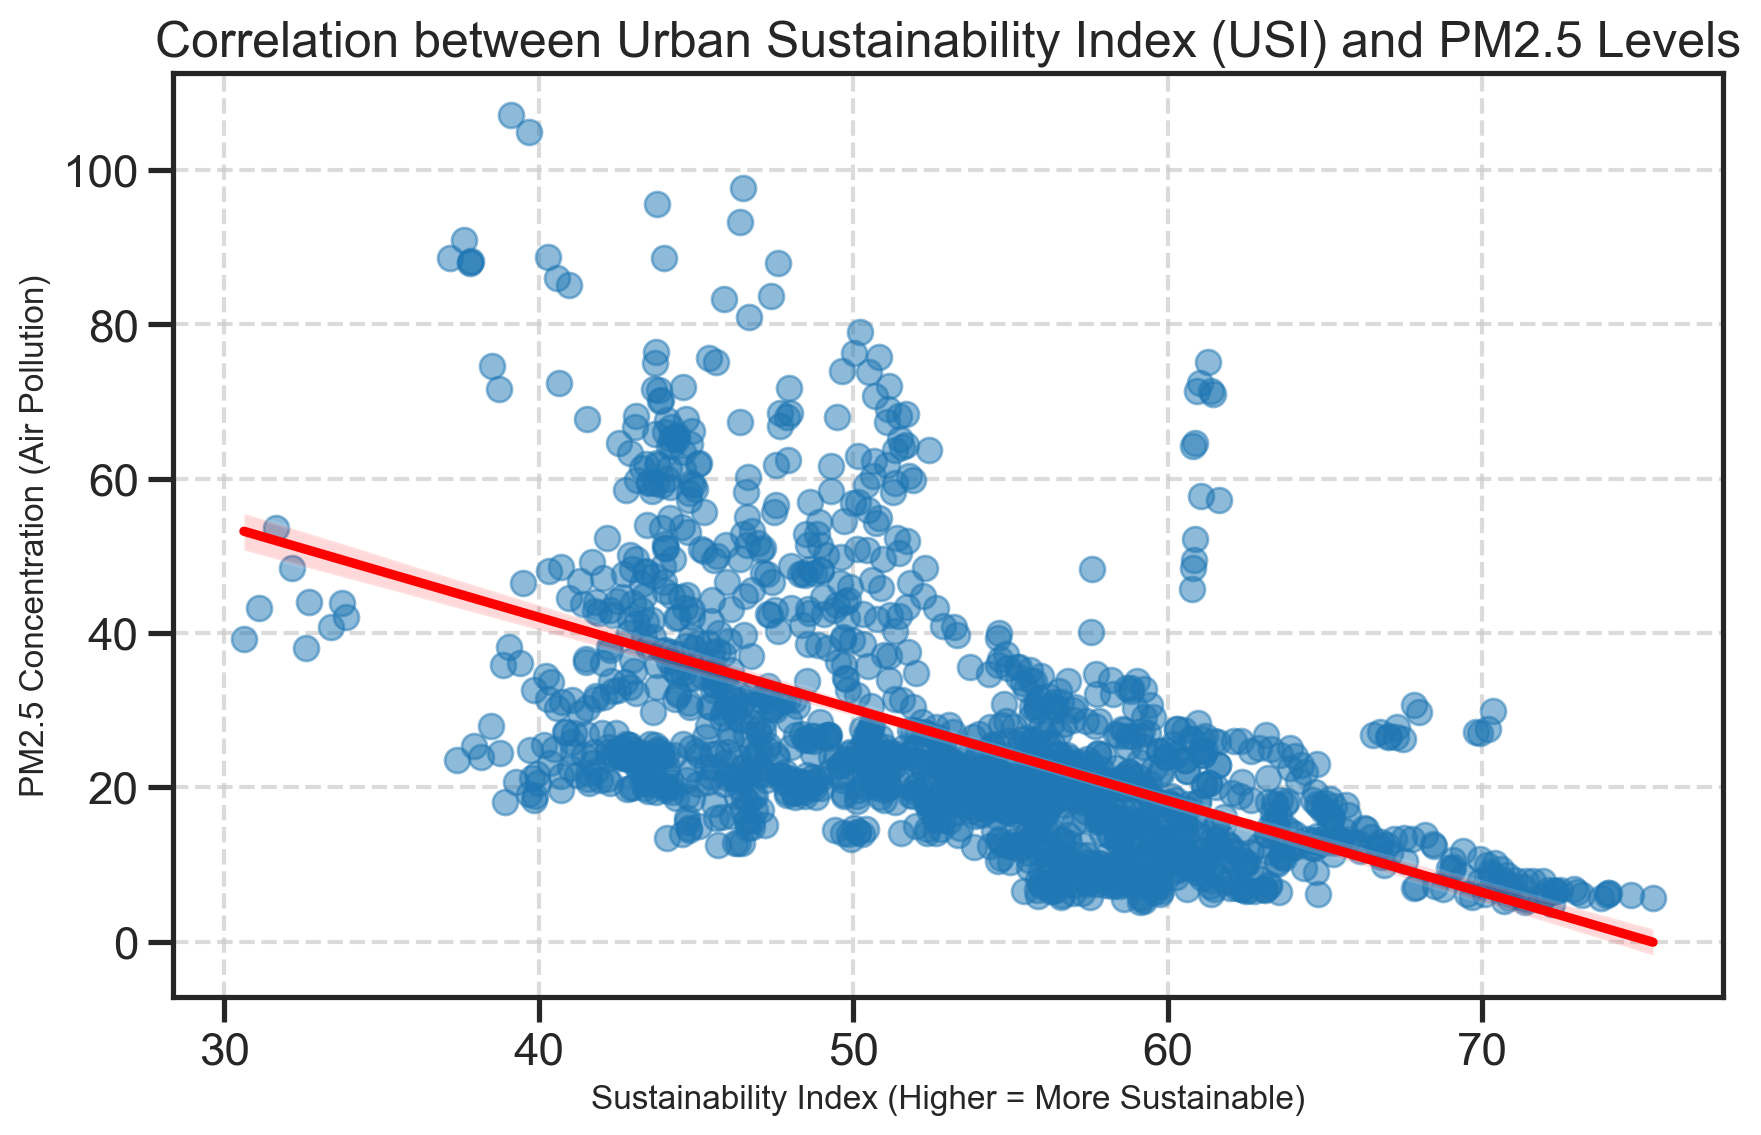

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='USI', y='pm25', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Correlation between Urban Sustainability Index (USI) and PM2.5 Levels')
plt.xlabel('Sustainability Index (Higher = More Sustainable)', fontsize=12)
plt.ylabel('PM2.5 Concentration (Air Pollution)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

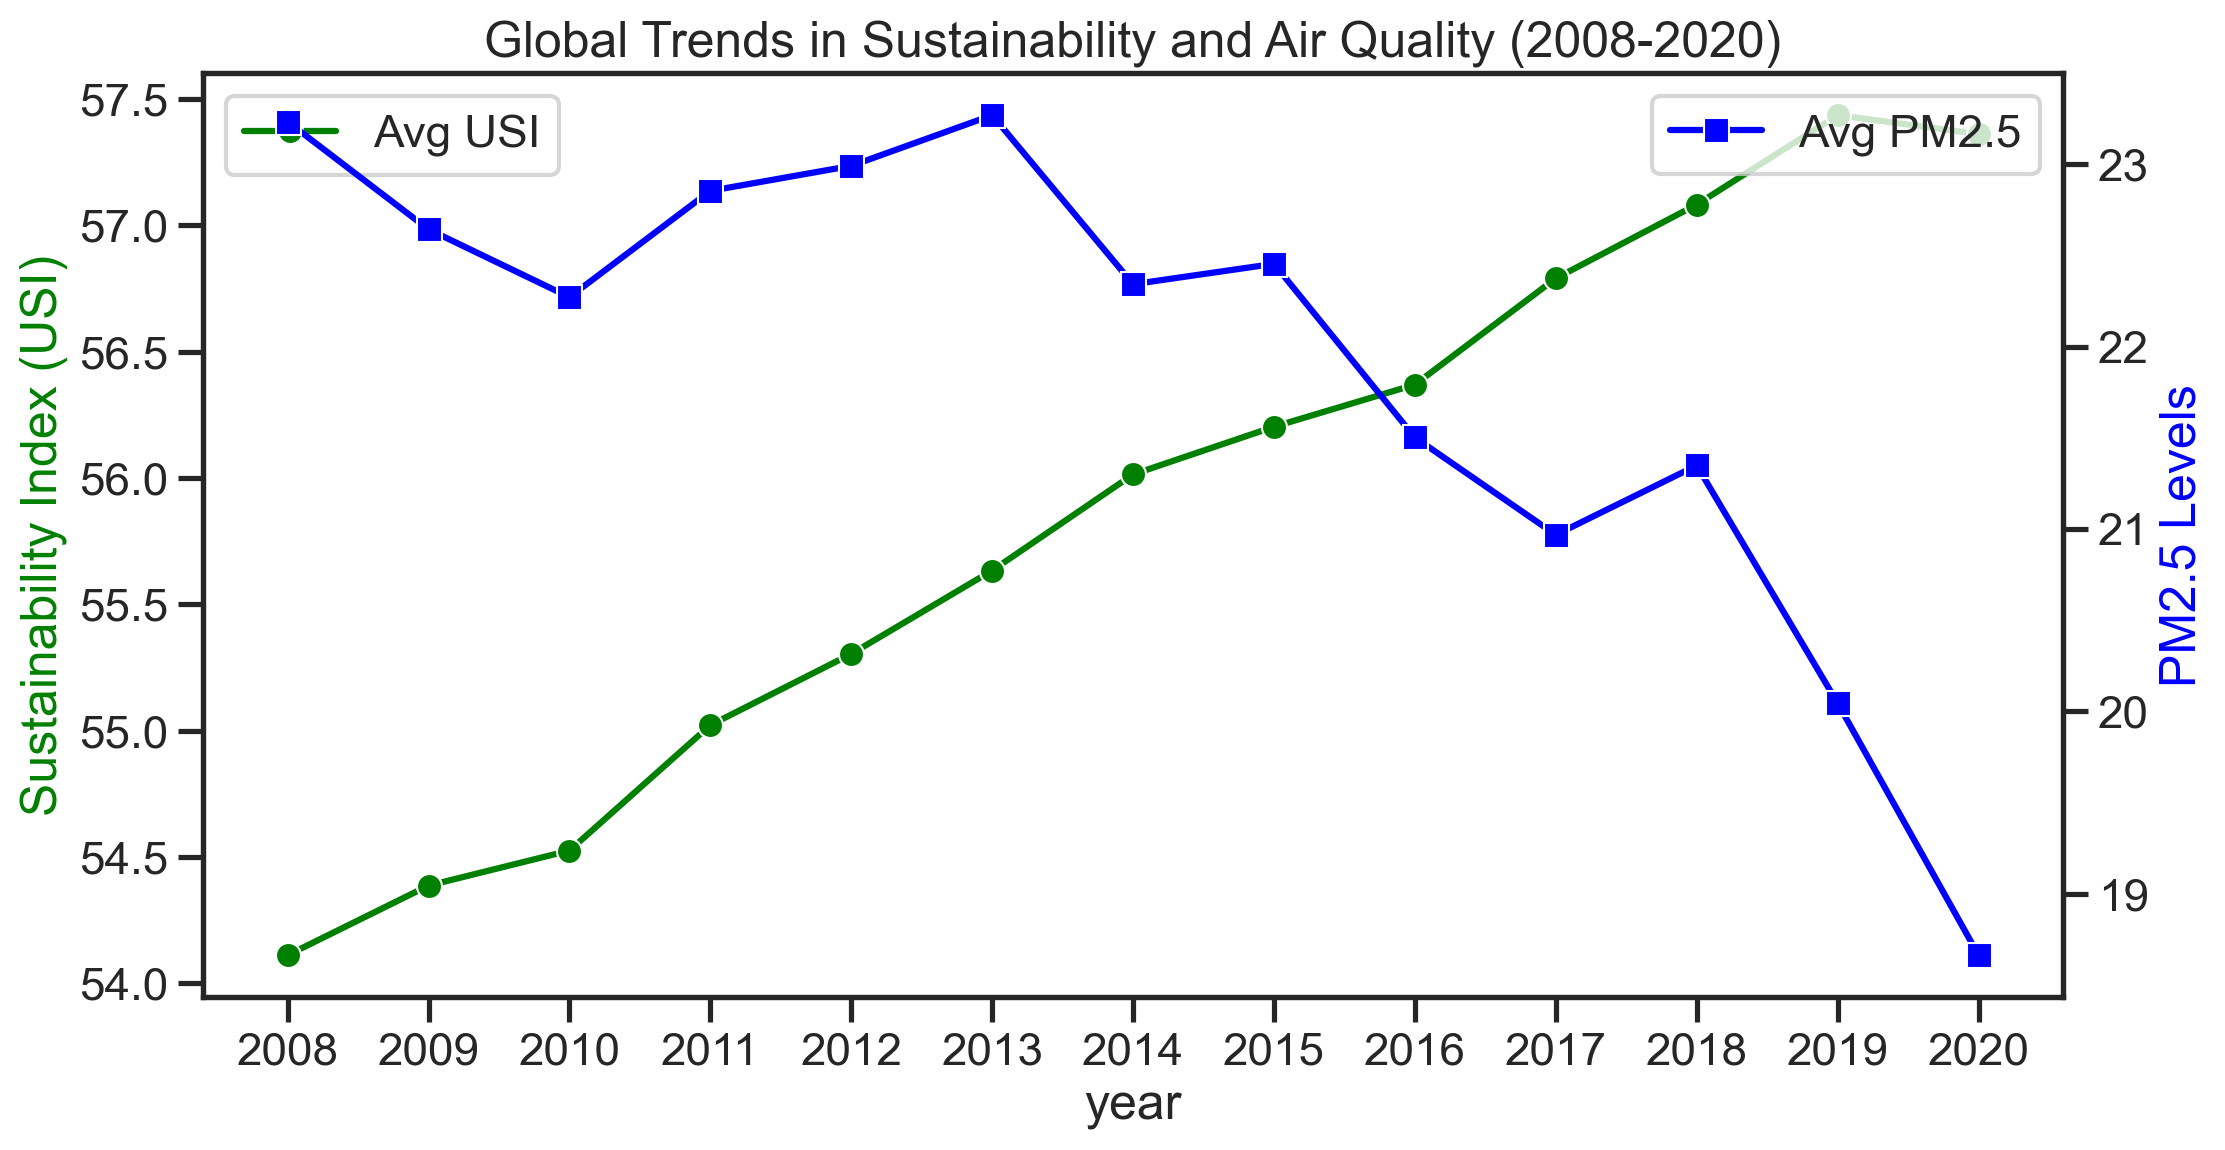

In [35]:
yearly_avg = df.groupby('year')[['pm25', 'USI']].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))

ax2 = ax1.twinx()
sns.lineplot(data=yearly_avg, x='year', y='USI', ax=ax1, color='green', marker='o', label='Avg USI')
sns.lineplot(data=yearly_avg, x='year', y='pm25', ax=ax2, color='blue', marker='s', label='Avg PM2.5')

ax1.set_ylabel('Sustainability Index (USI)', color='green')
ax2.set_ylabel('PM2.5 Levels', color='blue')
plt.title('Global Trends in Sustainability and Air Quality (2008-2020)')
plt.xticks(range(2008, 2021))
plt.show()

/var/folders/vp/npcvxcc52xqfjgmswcdds6yc0000gn/T/ipykernel_24417/2121425832.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_bottom, x='USI', y='country', palette='viridis')


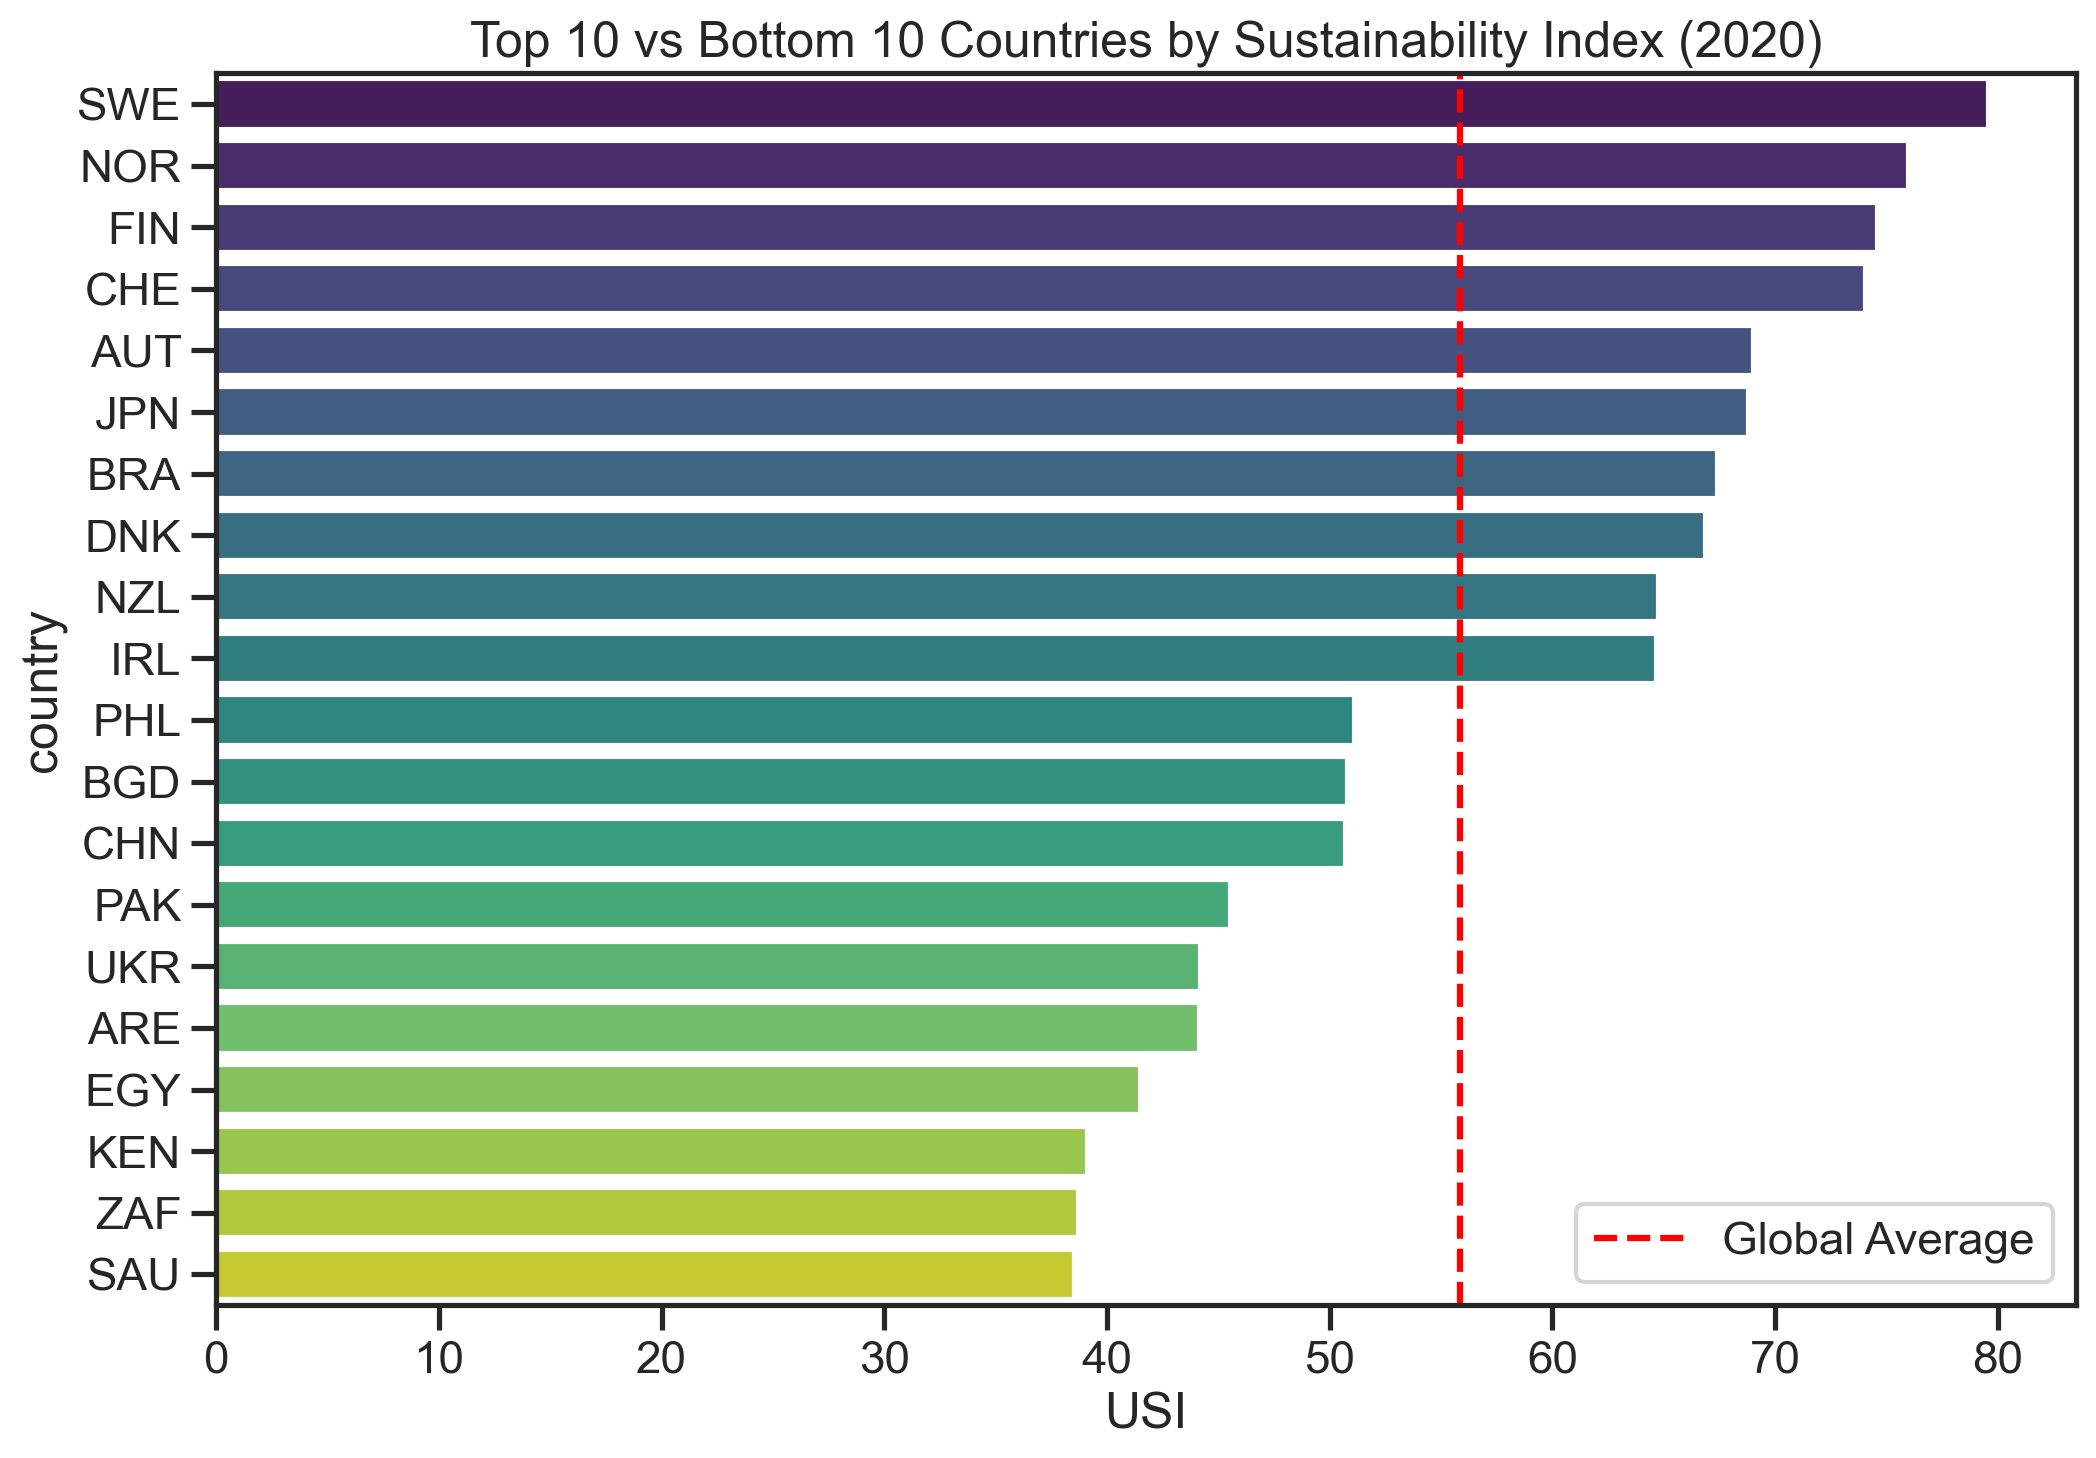

In [36]:
latest_data = df[df['year'] == 2020].sort_values('USI', ascending=False)
top_bottom = pd.concat([latest_data.head(10), latest_data.tail(10)])

plt.figure(figsize=(12, 8))
sns.barplot(data=top_bottom, x='USI', y='country', palette='viridis')
plt.title('Top 10 vs Bottom 10 Countries by Sustainability Index (2020)')
plt.axvline(df['USI'].mean(), color='red', linestyle='--', label='Global Average')
plt.legend()
plt.show()